#  Q5. Are there “outlier states” that shown unusually high conviction numbers for specific crimes?

### Q5.1 Which state has the most imbalanced ratio of Rape Convictions to Assault on Women ?

A very high Rape/Assault ratio suggests the system is only acting on the most serious cases and ignoring daily harassment/outraging modesty cases.

- Calculate Severity_Ratio = Avg_Rape / Avg_Assault.
- Calculate the Mean and SD of this ratio across all states.
- Calculate the Z-Score for each state: (Ratio - Mean) / SD.
- Identify states with Z-Score > 2.0

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('C:/Users/Anmol Sriwastava/OneDrive/Desktop/crime-to-conviction-analysis/data/processed/Cleaned_dataset_for_Q5.csv')

# Step 1: Calculate 5-year average per state
state_avg = df.groupby('state').agg(
    avg_rape=('rape', 'mean'),
    avg_assault=('assault_women', 'mean')
).reset_index()

# Step 2: Calculate ratio (handle division by zero)
state_avg['rape_assault_ratio'] = state_avg['avg_rape'] / state_avg['avg_assault'].replace(0, np.nan)

# Step 3: Calculate Z-score
mean_ratio = state_avg['rape_assault_ratio'].mean()
std_ratio = state_avg['rape_assault_ratio'].std()
state_avg['z_score'] = (state_avg['rape_assault_ratio'] - mean_ratio) / std_ratio

# Step 4: Find strong outliers (Z > 2)
outliers_q51 = state_avg[state_avg['z_score'] > 2].sort_values('z_score', ascending=False)

print(" States with unusually high Rape/Assault ratio (Z-score > 2):")
print(outliers_q51[['state', 'avg_rape', 'avg_assault', 'rape_assault_ratio', 'z_score']].round(2))

Q5.1 – States with unusually high Rape/Assault ratio (Z-score > 2):
          state  avg_rape  avg_assault  rape_assault_ratio  z_score
35  West Bengal     461.0          4.2              109.76     2.77
23      Mizoram      63.2          0.6              105.33     2.61


# Interpretation

- On average, for every 1 Assault on Women conviction, West Bengal has ~110 Rape convictions.
- This is highly unusual. Normally, Assault (lesser offence) should be much more common than Rape.
- This suggests possible systemic issues: either very low conviction rate for lesser sexual harassment cases, or extreme under-reporting of non-rape sexual offences.

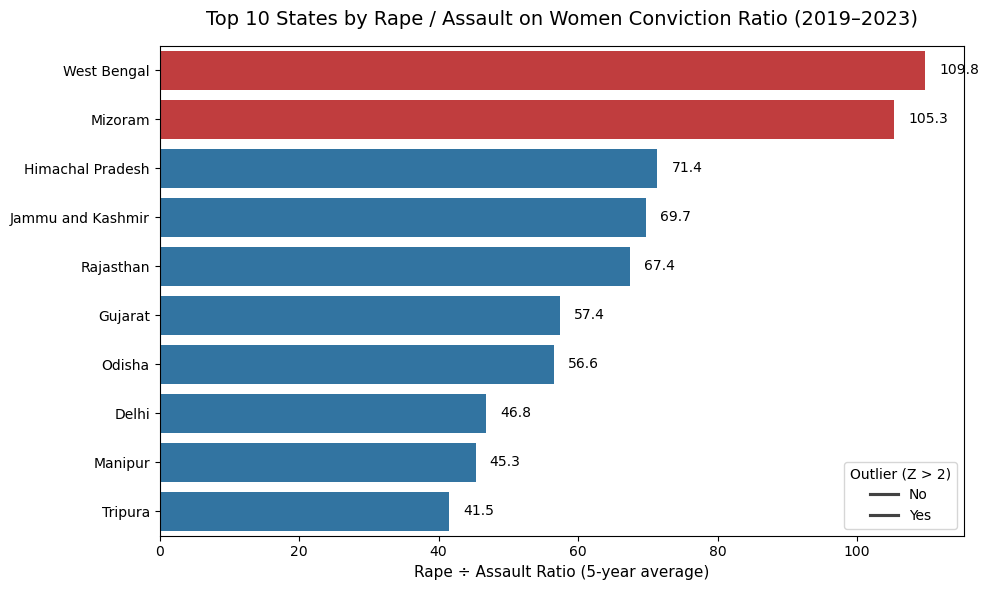

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting (top 10 + highlight outliers)
plot_data = state_avg.nlargest(10, 'rape_assault_ratio').copy()
plot_data['highlight'] = plot_data['state'].isin(['West Bengal', 'Mizoram'])

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=plot_data,
    y='state',
    x='rape_assault_ratio',
    hue='highlight',
    palette={True: '#d62728', False: '#1f77b4'},
    dodge=False
)

plt.title('Top 10 States by Rape / Assault on Women Conviction Ratio (2019–2023)', fontsize=14, pad=15)
plt.xlabel('Rape ÷ Assault Ratio (5-year average)', fontsize=11)
plt.ylabel('')
plt.legend(title='Outlier (Z > 2)', labels=['No', 'Yes'], loc='lower right')

# Add value labels
for i, v in enumerate(plot_data['rape_assault_ratio']):
    ax.text(v + 2, i, f'{v:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('q51_rape_assault_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

## Q5.2 Examine the Preparatory Offences: Prep. and Assembly for Dacoity. Which states have a zero count for this charge despite having high Actual Dacoity counts?

### Procedure
- Sum Dacoity (Col. 15) over 5 years for each state.
- Sum Prep. Dacoity (Col. 16) over 5 years.
- Find states where:
   - Dacoity sum > national median
   - Prep. Dacoity sum = 0

In [7]:

df = pd.read_csv('C:/Users/Anmol Sriwastava/OneDrive/Desktop/crime-to-conviction-analysis/data/processed/Cleaned_dataset_for_Q5.csv')

# Step 1: Sum over 5 years per state
state_sum = df.groupby('state')[['dacoity', 'prep_dacoity']].sum().reset_index()

# Step 2: Find median Dacoity
median_dacoity = state_sum['dacoity'].median()

# Step 3: Filter states with High Dacoity + Zero Prep
q52_outliers = state_sum[
    (state_sum['dacoity'] > median_dacoity) & 
    (state_sum['prep_dacoity'] == 0)
].sort_values('dacoity', ascending=False)

print("States with High Dacoity but ZERO Preparatory charges:")
print(q52_outliers)

States with High Dacoity but ZERO Preparatory charges:
Empty DataFrame
Columns: [state, dacoity, prep_dacoity]
Index: []


### Interpretation
- Every state that has above-median Dacoity convictions also has at least some Preparatory Dacoity convictions.
- There are no purely reactive states in this category.
- This is a positive finding, it indicates that states facing serious dacoity problems are using preventive policing (Section 399/402) to some degree.

## Q5.3  Which state shows a consistent, sharp decline (>50% drop) in Riots convictions from 2019 to 2023? Is this Peace or Impunity?


### Procedure
- Get 2019 and 2023 Riots value per state
- % Change = (Riots_2023 / Riots_2019 – 1) × 100
- Filter states where change < –50%
- Also show Murder % change for context

In [ ]:


df = pd.read_csv('C:/Users/Anmol Sriwastava/OneDrive/Desktop/crime-to-conviction-analysis/data/processed/Cleaned_dataset_for_Q5.csv')

# Step 1: Pivot to get 2019 and 2023 values
riots = df.pivot(index='state', columns='year', values='riots').reset_index()
murder = df.pivot(index='state', columns='year', values='murder').reset_index()

# Step 2: Calculate % change
riots['riots_pct_change'] = ((riots[2023] / riots[2019]) - 1) * 100
murder['murder_pct_change'] = ((murder[2023] / murder[2019]) - 1) * 100

# Step 3: Merge and filter
q53 = riots[['state', 2019, 2023, 'riots_pct_change']].merge(
    murder[['state', 'murder_pct_change']], on='state'
)

sharp_decline = q53[q53['riots_pct_change'] < -50].sort_values('riots_pct_change')

print(" States with >50% drop in Riots (2019–2023):")
print(sharp_decline.round(1))

Q5.3 – States with >50% drop in Riots (2019–2023):
year           state  2019  2023  riots_pct_change  murder_pct_change
3              Assam   2.0   0.0            -100.0               -5.4
5         Chandigarh   3.0   0.0            -100.0              -18.3
6       Chhattisgarh   6.0   0.0            -100.0              -29.2
10           Gujarat  19.0   0.0            -100.0               47.4
16            Kerala  32.0   0.0            -100.0               -1.5
35       West Bengal   9.0   0.0            -100.0               -6.8
32           Tripura   3.0   0.0            -100.0              -16.8
28         Rajasthan   8.0   0.0            -100.0              -27.5
27            Punjab  14.0   1.0             -92.9                0.9
11           Haryana  90.0   8.0             -91.1              -38.2
19    Madhya Pradesh  54.0  23.0             -57.4                6.7
4              Bihar  14.0   6.0             -57.1              -29.5


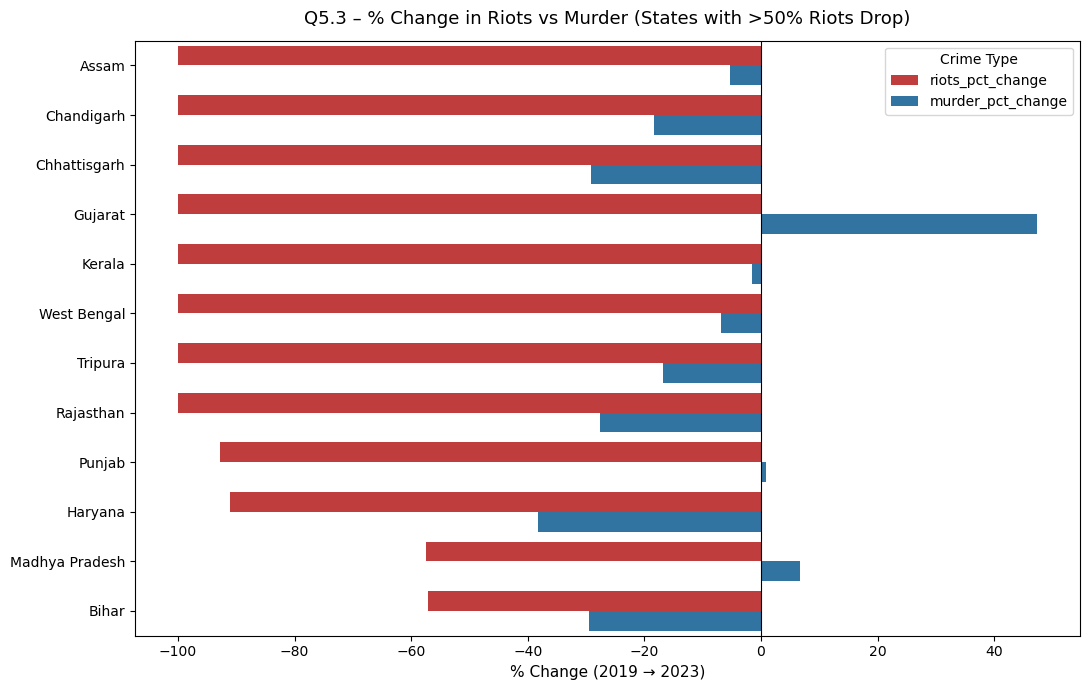

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only states with >50% riot drop
plot_df = sharp_decline.copy()
plot_df = plot_df.melt(id_vars='state', 
                       value_vars=['riots_pct_change', 'murder_pct_change'],
                       var_name='Crime', value_name='Pct_Change')

plt.figure(figsize=(11, 7))
ax = sns.barplot(data=plot_df, y='state', x='Pct_Change', hue='Crime', 
                 palette={'riots_pct_change': '#d62728', 'murder_pct_change': '#1f77b4'})

plt.axvline(0, color='black', linewidth=0.8)
plt.title('Q5.3 – % Change in Riots vs Murder (States with >50% Riots Drop)', fontsize=13, pad=12)
plt.xlabel('% Change (2019 → 2023)', fontsize=11)
plt.ylabel('')
plt.legend(title='Crime Type')
plt.tight_layout()
plt.savefig('q53_riots_murder_change.png', dpi=300, bbox_inches='tight')
plt.show()

## Interpretation
12 states recorded >50% drop in Riots. Several states (Assam, Chandigarh, Chhattisgarh, Gujarat, Kerala, etc.) recorded **zero** riot convictions in 2023.

**Notable Observation**:
- **Gujarat** shows -100% drop in Riots but **+47.4% rise in Murder**. This pattern is suspicious and may indicate reclassification of riot cases as individual murders to keep official "communal violence" numbers low.
- States like **Haryana** (-91% Riots, -38% Murder) and **Punjab** show declines in both, suggesting more genuine improvement in public order.

## Q5.4 For each state, calculate two metrics:
1. Average Annual Growth Rate (CAGR) of Total Convicts (Col. 28) from 2019‑2023 (trend direction).
2. Coefficient of Variation (CV) of the annual Total Convicts (volatility).
Plot states on a scatter plot with CAGR on X‑axis and CV on Y‑axis. Divide into four quadrants using national
medians. Which states fall into the "High Growth, High Volatility" quadrant (most unpredictable expansion)?

States with High CAGR + High CV = prison population is growing fast and unpredictably.

We divide states into 4 quadrants using national median values:

- High Growth + High Volatility → Most stressed (top-right)
- High Growth + Low Volatility → Manageable growth
- Low Growth + High Volatility → Unstable but slow
- Low Growth + Low Volatility → Stable (best for planning)

In [ ]:


df = pd.read_csv('C:/Users/Anmol Sriwastava/OneDrive/Desktop/crime-to-conviction-analysis/data/processed/Cleaned_dataset_for_Q5.csv')

# Step 1: Create state-year panel
panel = df.pivot(index='state', columns='year', values='total_convicts')

# Step 2: Calculate CAGR (2019-2023)
panel['cagr'] = (panel[2023] / panel[2019]) ** (1/4) - 1

# Step 3: Calculate CV (volatility)
panel['mean'] = panel[[2019,2020,2021,2022,2023]].mean(axis=1)
panel['std'] = panel[[2019,2020,2021,2022,2023]].std(axis=1)
panel['cv'] = panel['std'] / panel['mean']

# Step 4: National medians
med_cagr = panel['cagr'].median()
med_cv = panel['cv'].median()

# Step 5: Assign quadrants
def get_quadrant(row):
    if row['cagr'] > med_cagr and row['cv'] > med_cv:
        return 'High Growth + High Volatility ⚠️'
    elif row['cagr'] > med_cagr:
        return 'High Growth + Low Volatility'
    elif row['cv'] > med_cv:
        return 'Low Growth + High Volatility'
    else:
        return 'Stable'

panel['quadrant'] = panel.apply(get_quadrant, axis=1)

# Step 6: Show stressed states
stress = panel[panel['quadrant'].str.contains('High Growth.*High Volatility')]
print("States in High Growth + High Volatility quadrant (most stressed):")
print(stress[['cagr', 'cv', 'quadrant']].round(3).sort_values('cagr', ascending=False))

Q5.4 – States in High Growth + High Volatility quadrant (most stressed):
year             cagr     cv                          quadrant
state                                                         
Meghalaya       0.138  0.276  High Growth + High Volatility ⚠️
Puducherry      0.086  0.148  High Growth + High Volatility ⚠️
Nagaland        0.052  0.178  High Growth + High Volatility ⚠️
Madhya Pradesh  0.018  0.188  High Growth + High Volatility ⚠️
Kerala          0.005  0.161  High Growth + High Volatility ⚠️
Punjab         -0.001  0.314  High Growth + High Volatility ⚠️
Odisha         -0.019  0.140  High Growth + High Volatility ⚠️


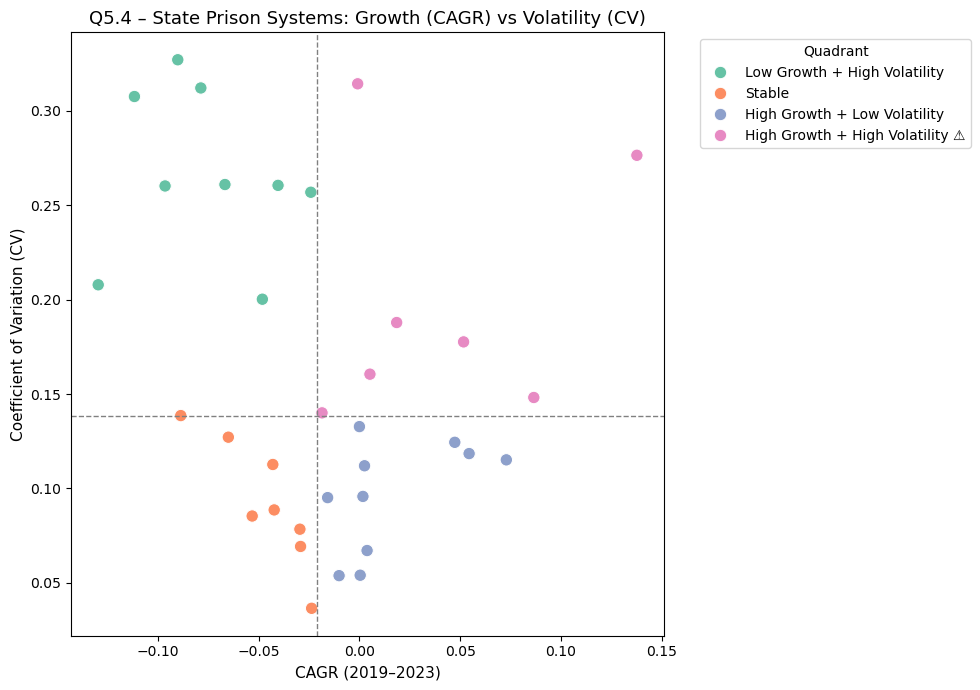

In [11]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=panel, x='cagr', y='cv', hue='quadrant', s=80, palette='Set2')

plt.axvline(med_cagr, color='gray', linestyle='--', linewidth=1)
plt.axhline(med_cv, color='gray', linestyle='--', linewidth=1)

plt.title('Q5.4 – State Prison Systems: Growth (CAGR) vs Volatility (CV)', fontsize=13)
plt.xlabel('CAGR (2019–2023)', fontsize=11)
plt.ylabel('Coefficient of Variation (CV)', fontsize=11)
plt.legend(title='Quadrant', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('q54_quadrant_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

7 states fall in the **High Growth + High Volatility** quadrant (most stressed):

- **Meghalaya** (+13.8% CAGR, CV 0.276) — highest stress
- Puducherry, Nagaland, Madhya Pradesh, Kerala, Punjab, and Odisha also show concerning combinations of growth and unpredictability.

These states face significant challenges in budgeting, staffing, and infrastructure planning due to rapid and volatile increases in prison population.

## Q 5.5 Consider the crime Counterfeiting (Col. 22) . Identify all states that reported at least one conviction for counterfeiting in all five years (2019‑2023). Among these states, which has the lowest total convictions over the 5‑year period? (i.e., the smallest consistent presence of this rare crime.)


### Why is it needed ?
- Counterfeiting is a rare, specialised crime.
- Consistent convictions every year = the state has sustained capacity (Economic Offences Wing / SIT is functional).
- The state with the smallest consistent total shows the minimum viable capacity needed to keep this rare crime under control.

In [ ]:
import pandas as pd

df = pd.read_csv('C:/Users/Anmol Sriwastava/OneDrive/Desktop/crime-to-conviction-analysis/data/processed/Cleaned_dataset_for_Q5.csv')

# Step 1: Pivot Counterfeiting data
counter = df.pivot(index='state', columns='year', values='counterfeiting')

# Step 2: Filter states with at least 1 conviction every year
consistent = counter[(counter[2019] > 0) & 
                     (counter[2020] > 0) & 
                     (counter[2021] > 0) & 
                     (counter[2022] > 0) & 
                     (counter[2023] > 0)].copy()

# Step 3: Calculate 5-year total and find the lowest
consistent['total_5yr'] = consistent.sum(axis=1)
lowest = consistent.nsmallest(3, 'total_5yr')

print(" States with consistent Counterfeiting convictions every year (2019–2023):")
print(lowest[['total_5yr']].sort_values('total_5yr'))

Q5.5 – States with consistent Counterfeiting convictions every year (2019–2023):
year         total_5yr
state                 
Delhi             16.0
Tamil Nadu        23.0
Uttarakhand       25.0


### Interpretation
Only 3 states maintained consistent convictions every year:

- **Delhi** (16 total) — lowest consistent presence
- Tamil Nadu (23)
- Uttarakhand (25)

Delhi represents the **minimum viable capacity** required to sustain investigative and prosecutorial focus on this rare, specialised crime. Most states show zero or irregular activity in this area.

C:\Users\Anmol Sriwastava\AppData\Local\Temp\ipykernel_40572\135670325.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=lowest.reset_index(), x='state', y='total_5yr',


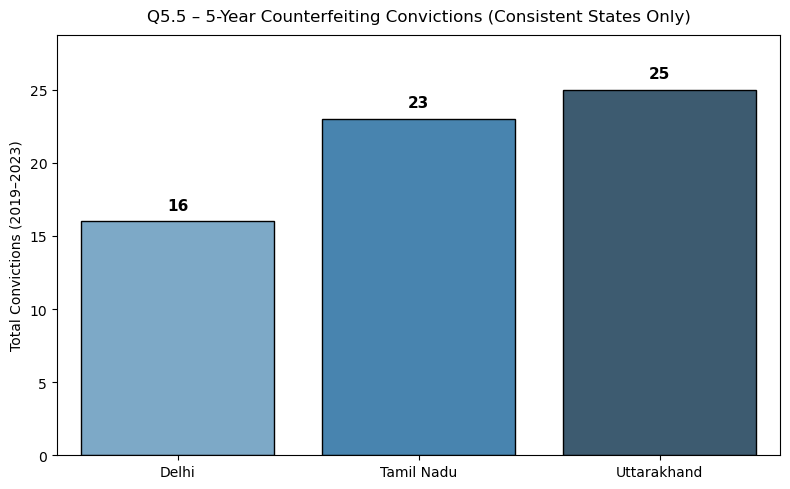

In [16]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=lowest.reset_index(), x='state', y='total_5yr', 
                 palette='Blues_d', edgecolor='black')

plt.title('Q5.5 – 5-Year Counterfeiting Convictions (Consistent States Only)', fontsize=12, pad=10)
plt.xlabel('')
plt.ylabel('Total Convictions (2019–2023)')

for i, v in enumerate(lowest['total_5yr']):
    ax.text(i, v + 0.8, str(int(v)), ha='center', fontsize=11, fontweight='bold')

plt.ylim(0, max(lowest['total_5yr']) * 1.15)
plt.tight_layout()
plt.savefig('q55_counterfeiting.png', dpi=300, bbox_inches='tight')
plt.show()